**Evaluating Efficacy of Conventional CNN model and Pre-trained CNN model, VGG16 on Detecting Pneumonia from Chest X-ray Images**

# Library and packages import

**Import packages & functions**

In [ ]:
# Loading necessary libraries and packages
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import random
import pandas as pd

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.applications import VGG16
from keras.preprocessing.image import ImageDataGenerator
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, roc_curve
from tensorflow.keras import callbacks
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization

In [ ]:
# Setting seed for reproducibility
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

In [ ]:
# Mounting drive to google colab
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Data Loading and Preparation

In [ ]:
# Setting up path for training & testing data

train_path = '/content/drive/MyDrive/chest_xray/train'
test_path = '/content/drive/MyDrive/chest_xray/test'
val_path = '/content/drive/MyDrive/chest_xray/val'

**Data Loading**

In [ ]:
# Setting constants
image_size = 224
batch_size = 32

In [ ]:
# Data loading - Original images without any processing done

train_data = tf.keras.utils.image_dataset_from_directory(
    train_path
)

test_data = tf.keras.utils.image_dataset_from_directory(
    test_path
)

val_data = tf.keras.utils.image_dataset_from_directory(
    val_path
)

Found 5216 files belonging to 2 classes.
Found 624 files belonging to 2 classes.
Found 16 files belonging to 2 classes.


# Data Exploration

**Data Exploration**

<ipython-input-6-bc78e6611a64>:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=label_names, palette='mako')


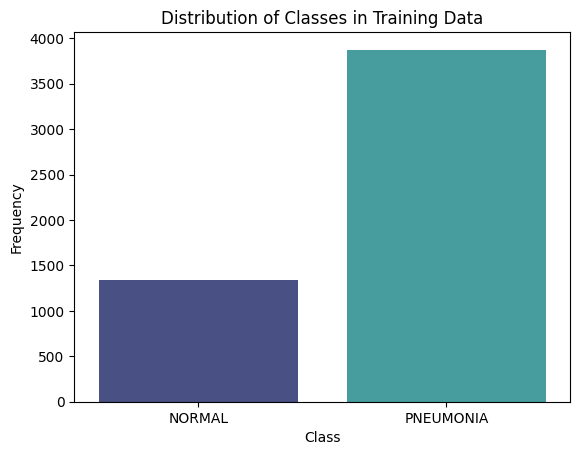

In [ ]:
# Initialize a list to store the labels
labels = []

# Iterate over the dataset and collect all labels
for images, batch_labels in train_data:
    labels.extend(batch_labels.numpy())

# Convert numeric labels to actual class names
class_names = train_data.class_names
label_names = [class_names[label] for label in labels]

# Create a histogram using seaborn
sns.countplot(x=label_names, palette='mako')
plt.title('Distribution of Classes in Training Data')
plt.xlabel('Class')
plt.ylabel('Frequency')
plt.show()

In [ ]:
# Visualizing the images for both "normal" and "pneumonia"

def plot_images(dataset, num_images):
    plt.figure(figsize=(10, 10))
    for images, labels in dataset.take(1):
        for i in range(num_images):
            ax = plt.subplot(5,5, i + 1)
            plt.imshow(images[i].numpy().astype("uint8"), cmap = 'gray')
            plt.title(train_data.class_names[labels[i]])
            plt.axis("off")
    plt.show()

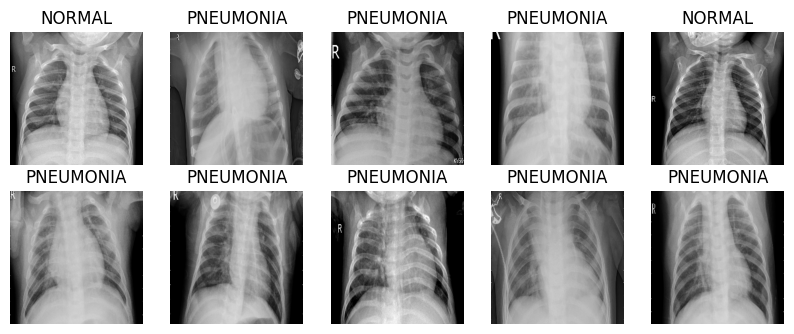

In [ ]:
# Plot images of X-ray training data
plot_images(train_data, 10)

# Data Preprocessing & Model Preparation


**Data Preprocessing**

In [ ]:
# Data Preprocessing - Data normalization and augmentation

# Augmentation setup and normalization for testing set
augmented_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    width_shift_range=0.05,
    height_shift_range=0.05,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=False,
    vertical_flip=False,
    fill_mode='nearest'
)

# No augmentation for the train and validation set, only normalization
non_augmented_datagen = ImageDataGenerator(
    rescale=1./255
)

In [ ]:
# Create generators - For custom CNN

train_gen = augmented_datagen.flow_from_directory(
    directory=train_path,
    target_size=(image_size, image_size),
    batch_size=batch_size,
    #color_mode='grayscale',
    class_mode='binary',
    shuffle=True,
    seed=42
)

test_gen = non_augmented_datagen.flow_from_directory(
    directory=test_path,
    target_size=(image_size, image_size),
    batch_size=batch_size,
    #color_mode='grayscale',
    class_mode='binary',
    shuffle=False
)

val_gen = non_augmented_datagen.flow_from_directory(
    directory=val_path,
    target_size=(image_size, image_size),
    batch_size=batch_size,
    #color_mode='grayscale',
    class_mode='binary',
    shuffle=False
)

Found 5216 images belonging to 2 classes.
Found 624 images belonging to 2 classes.
Found 16 images belonging to 2 classes.


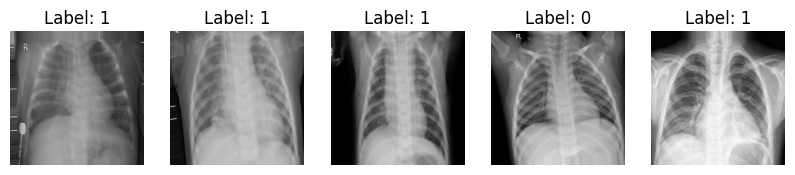

In [ ]:
# Visualizing the images for both "normal" and "pneumonia" after augmentation
images, labels = next(train_gen)

# Number of images to display
num_images = 5

plt.figure(figsize=(10, 10))
for i in range(num_images):
    ax = plt.subplot(1, num_images, i + 1)
    plt.imshow(images[i].reshape(image_size, image_size), cmap='gray')
    plt.title(f'Label: {int(labels[i])}')
    plt.axis("off")

**Preparing necessary parameters for models**

In [ ]:
# Calculate the number of samples for each class
class_counts = np.bincount(train_gen.labels)
classes = list(train_gen.class_indices.keys())  # class names extracted from the generator
class_indices = np.array(list(train_gen.class_indices.values()))  # indices as per the class

print("Class counts:", dict(zip(classes, class_counts)))

Class counts: {'NORMAL': 1341, 'PNEUMONIA': 3875}


In [ ]:
# To mitigate the effects of imbalanced dataset, using normal loss function would introduce biases
# Therefore, introduce weighted loss function - assigning highest weights for minority class
# Minority class = "Normal"

# Using 'balanced' to automatically adjust weights inversely proportional to class frequencies
weights = compute_class_weight(class_weight='balanced', classes=np.unique(train_gen.labels), y=train_gen.labels)
class_weights = dict(zip(class_indices, weights))

print("Class weights:", class_weights)

Class weights: {0: 1.9448173005219984, 1: 0.6730322580645162}


In [ ]:
# Setting callbacks for tuning

# Setting up Early Stopping, using validation loss to monitor
early_stopper = EarlyStopping(monitor='val_loss', mode='min', patience=5,
                              restore_best_weights=True)

# Setting up learning rate, using validation loss to monitor
learning_rate = callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=3, verbose=1)

# Setting up model checkpoint
model_checkpoint = ModelCheckpoint('best_model.h5', monitor = 'val_loss', save_best_only = True)

# Proposed Model || CUSTOM CNN

In [ ]:
def build_model():

  #Input shape = [width, height, color channels]
  inputs = layers.Input(shape=(image_size, image_size, 3))

  # First block
  x = layers.Conv2D(filters=16, kernel_size=3, padding='same')(inputs)
  x = layers.BatchNormalization()(x)
  x = layers.Activation('relu')(x)
  x = layers.MaxPool2D()(x)
  #x = layers.Dropout(0.2)(x)

  # Second block
  x = layers.Conv2D(filters=32, kernel_size=3, padding='same')(x)
  x = layers.BatchNormalization()(x)
  x = layers.Activation('relu')(x)
  x = layers.MaxPool2D()(x)
  #x = layers.Dropout(0.2)(x)

 # Third block
  x = layers.Conv2D(filters=64, kernel_size=3, padding='same')(x)
  x = layers.BatchNormalization()(x)
  x = layers.Activation('relu')(x)
  x = layers.MaxPool2D()(x)
  #x = layers.Dropout(0.2)(x)

 # Flatten layer
  x = layers.Flatten()(x)

# Dense layer
  x = layers.Dense(units=64, activation='relu')(x)
  x = layers.Dropout(0.2)(x)

# Output layer
  outputs = layers.Dense(units=1, activation='sigmoid')(x)

  model = keras.Model(inputs=inputs, outputs=outputs)
  return model


In [ ]:
# Compile CNN model
model = build_model()

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

In [ ]:
# Summary of custom CNN
model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 conv2d (Conv2D)             (None, 224, 224, 16)      448       
                                                                 
 batch_normalization (Batch  (None, 224, 224, 16)      64        
 Normalization)                                                  
                                                                 
 activation (Activation)     (None, 224, 224, 16)      0         
                                                                 
 max_pooling2d (MaxPooling2  (None, 112, 112, 16)      0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 112, 112, 32)      4640  

# Training & Evaluation: CNN Model - 1

In [ ]:
# Training Model #1 (Default LR - Using only early_stopper)
history1 = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=20,
    class_weight = class_weights,
    callbacks = [early_stopper]
)

Epoch 1/20
163/163 [==============================] - 1028s 6s/step - loss: 0.4808 - accuracy: 0.8461 - val_loss: 9.0251 - val_accuracy: 0.5000
Epoch 2/20
163/163 [==============================] - 117s 720ms/step - loss: 0.2036 - accuracy: 0.9225 - val_loss: 5.3461 - val_accuracy: 0.5000
Epoch 3/20
163/163 [==============================] - 119s 732ms/step - loss: 0.2135 - accuracy: 0.9212 - val_loss: 0.6435 - val_accuracy: 0.5625
Epoch 4/20
163/163 [==============================] - 119s 726ms/step - loss: 0.1812 - accuracy: 0.9402 - val_loss: 0.5361 - val_accuracy: 0.8125
Epoch 5/20
163/163 [==============================] - 118s 724ms/step - loss: 0.1850 - accuracy: 0.9388 - val_loss: 2.6901 - val_accuracy: 0.5000
Epoch 6/20
163/163 [==============================] - 118s 722ms/step - loss: 0.1758 - accuracy: 0.9402 - val_loss: 2.6692 - val_accuracy: 0.5625
Epoch 7/20
163/163 [==============================] - 121s 738ms/step - loss: 0.1607 - accuracy: 0.9463 - val_loss: 0.9410 - v

In [ ]:
# Check if early stopping was triggered
if early_stopper.stopped_epoch > 0:
    print(f"Training was stopped early at epoch: {early_stopper.stopped_epoch + 1}")
else:
    print("Training completed without early stopping.")

Training was stopped early at epoch: 9


20/20 [==============================] - 129s 7s/step - loss: 0.4929 - accuracy: 0.7788
Test Accuracy: 77.88%
163/163 [==============================] - 114s 701ms/step - loss: 0.2222 - accuracy: 0.9118
Train Accuracy: 91.18%


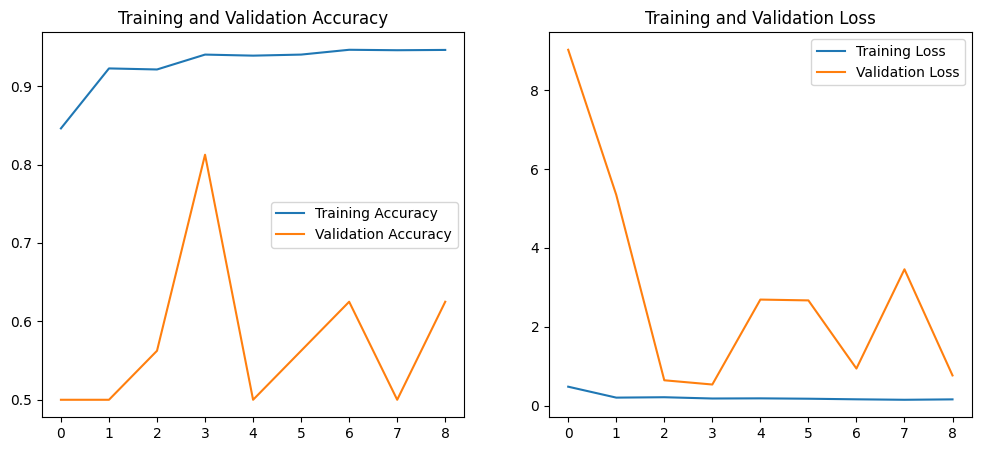

In [ ]:
# Evaluate the model
test_loss, test_acc = model.evaluate(test_gen)
print(f"Test Accuracy: {test_acc*100:.2f}%")

train_loss, train_acc = model.evaluate(train_gen)
print(f"Train Accuracy: {train_acc*100:.2f}%")

# Plot the training history for accuracy and loss
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history1.history['accuracy'], label='Training Accuracy')
plt.plot(history1.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history1.history['loss'], label='Training Loss')
plt.plot(history1.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()


In [ ]:
# Evaluate / Predict on test data
test_loss, test_acc = model.evaluate(test_gen)
print(f"Test Accuracy: {test_acc*100:.2f}%")

y_pred = model.predict(test_gen, steps=len(test_gen))
y_pred = np.round(y_pred).astype(int)
y_true = test_gen.classes
y_true = y_true[:len(y_pred)]

20/20 [==============================] - 7s 310ms/step - loss: 0.4929 - accuracy: 0.7788
Test Accuracy: 77.88%
20/20 [==============================] - 7s 325ms/step


In [ ]:
# Classification Report
print(confusion_matrix(test_gen.classes, y_pred > 0.5))
pd.DataFrame(classification_report(test_gen.classes, y_pred > 0.5, output_dict=True))

[[102 132]
 [  6 384]]


,0,1,accuracy,macro avg,weighted avg
precision,0.944444,0.744186,0.778846,0.844315,0.819283
recall,0.435897,0.984615,0.778846,0.710256,0.778846
f1-score,0.596491,0.847682,0.778846,0.722087,0.753486
support,234.000000,390.000000,0.778846,624.000000,624.000000


In [ ]:
# ROC AUC score
roc_auc = roc_auc_score(y_true, y_pred)
print(f"ROC AUC: {roc_auc:.2f}")

ROC AUC: 0.71


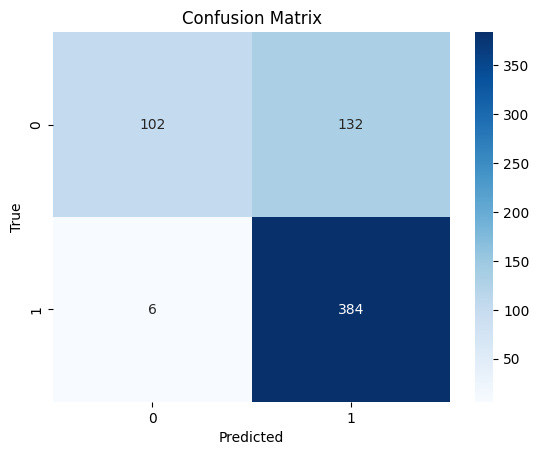

In [ ]:
# Plot confusion matrix heatmap
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

In [ ]:
tf.keras.backend.clear_session()

# Training and evaluation: CNN Model -2

In [ ]:
# Training Model #2 (With LR tuning on-the-fly)
history2 = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=20,
    class_weight = class_weights,
    callbacks = [early_stopper, learning_rate, model_checkpoint]
)

Epoch 1/20
163/163 [==============================] - 2813s 17s/step - loss: 0.4806 - accuracy: 0.8503 - val_loss: 7.7726 - val_accuracy: 0.5000 - lr: 0.0010


/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


Epoch 2/20
163/163 [==============================] - 119s 731ms/step - loss: 0.1996 - accuracy: 0.9195 - val_loss: 4.5130 - val_accuracy: 0.5000 - lr: 0.0010
Epoch 3/20
163/163 [==============================] - 121s 742ms/step - loss: 0.1917 - accuracy: 0.9308 - val_loss: 0.4725 - val_accuracy: 0.6250 - lr: 0.0010
Epoch 4/20
163/163 [==============================] - 121s 739ms/step - loss: 0.1633 - accuracy: 0.9408 - val_loss: 0.5734 - val_accuracy: 0.5625 - lr: 0.0010
Epoch 5/20
163/163 [==============================] - 121s 742ms/step - loss: 0.1544 - accuracy: 0.9469 - val_loss: 0.7855 - val_accuracy: 0.6250 - lr: 0.0010
Epoch 6/20
163/163 [==============================] - 123s 753ms/step - loss: 0.1617 - accuracy: 0.9431 - val_loss: 0.2344 - val_accuracy: 0.8125 - lr: 0.0010
Epoch 7/20
163/163 [==============================] - 121s 742ms/step - loss: 0.1726 - accuracy: 0.9459 - val_loss: 1.5867 - val_accuracy: 0.5000 - lr: 0.0010
Epoch 8/20
163/163 [==========================

In [ ]:
# Check if early stopping was triggered
if early_stopper.stopped_epoch > 0:
    print(f"Training was stopped early at epoch: {early_stopper.stopped_epoch + 1}")
else:
    print("Training completed without early stopping.")

Training was stopped early at epoch: 11


20/20 [==============================] - 404s 21s/step - loss: 0.3031 - accuracy: 0.8894
Test Accuracy: 88.94%
163/163 [==============================] - 121s 743ms/step - loss: 0.1569 - accuracy: 0.9423
Train Accuracy: 94.23%


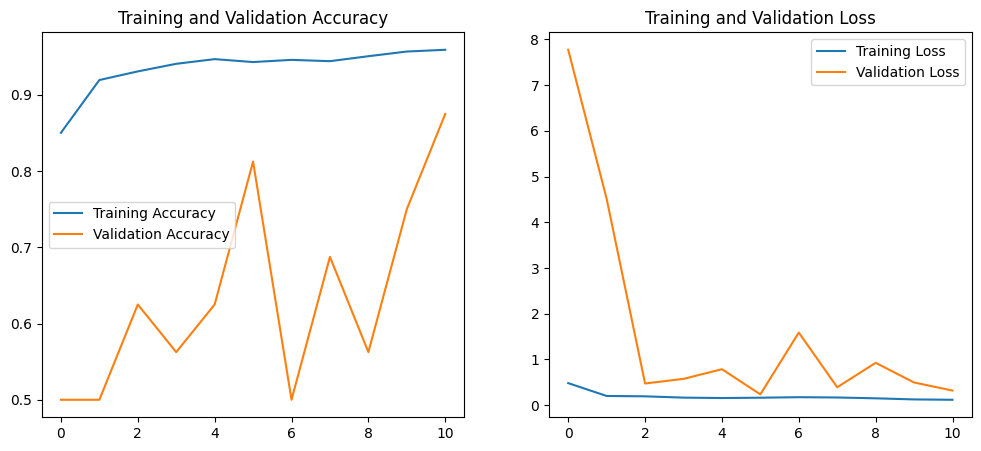

In [ ]:
# Evaluate the model
test_loss, test_acc = model.evaluate(test_gen)
print(f"Test Accuracy: {test_acc*100:.2f}%")

train_loss, train_acc = model.evaluate(train_gen)
print(f"Train Accuracy: {train_acc*100:.2f}%")

# Plot the training history for accuracy and loss
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history2.history['accuracy'], label='Training Accuracy')
plt.plot(history2.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history2.history['loss'], label='Training Loss')
plt.plot(history2.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()


In [ ]:
# Evaluate / Predict on test data
test_loss, test_acc = model.evaluate(test_gen)
print(f"Test Accuracy: {test_acc*100:.2f}%")

y_pred = model.predict(test_gen, steps=len(test_gen))
y_pred = np.round(y_pred).astype(int)
y_true = test_gen.classes
y_true = y_true[:len(y_pred)]

20/20 [==============================] - 9s 426ms/step - loss: 0.3031 - accuracy: 0.8894
Test Accuracy: 88.94%
20/20 [==============================] - 8s 356ms/step


In [ ]:
# Classification report
print(confusion_matrix(test_gen.classes, y_pred > 0.5))
pd.DataFrame(classification_report(test_gen.classes, y_pred > 0.5, output_dict=True))

[[196  38]
 [ 31 359]]


,0,1,accuracy,macro avg,weighted avg
precision,0.863436,0.904282,0.889423,0.883859,0.888965
recall,0.837607,0.920513,0.889423,0.879060,0.889423
f1-score,0.850325,0.912325,0.889423,0.881325,0.889075
support,234.000000,390.000000,0.889423,624.000000,624.000000


In [ ]:
# ROC AUC
roc_auc = roc_auc_score(y_true, y_pred)
print(f"ROC AUC: {roc_auc:.2f}")

ROC AUC: 0.88


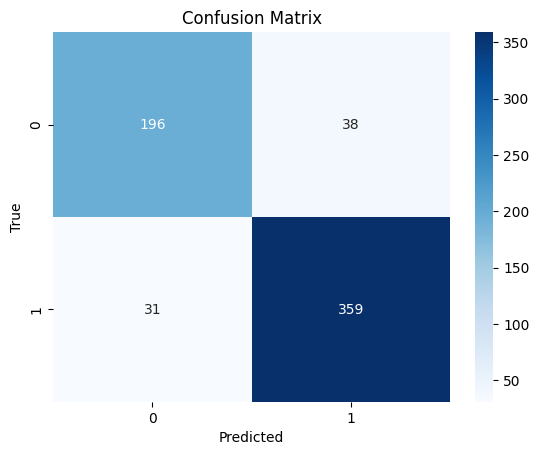

In [ ]:
# Plot confusion matrix heatmap
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

In [ ]:
tf.keras.backend.clear_session()

# Pre-trained Model || VGG16

In [ ]:
# Create generators suitable for VGG16

train_gen_rgb = augmented_datagen.flow_from_directory(
    directory=train_path,
    target_size=(image_size, image_size),
    batch_size=batch_size,
    color_mode='rgb',
    class_mode='binary',
    shuffle=True,
    seed=42
)

test_gen_rgb = non_augmented_datagen.flow_from_directory(
    directory=test_path,
    target_size=(image_size, image_size),
    batch_size=batch_size,
    color_mode='rgb',
    class_mode='binary',
    shuffle=False
)

val_gen_rgb = non_augmented_datagen.flow_from_directory(
    directory=val_path,
    target_size=(image_size, image_size),
    batch_size=batch_size,
    color_mode='rgb',
    class_mode='binary',
    shuffle=False
)

Found 5216 images belonging to 2 classes.
Found 624 images belonging to 2 classes.
Found 16 images belonging to 2 classes.


In [ ]:
# Load the pre-trained VGG16 model without top layer
base_model = VGG16(weights='imagenet', include_top=False,
                   input_shape=(224, 224, 3))

# Freeze base model layers
for layer in base_model.layers:
    layer.trainable = False

# Adding custom layers

# Flatten layers from base model output
x = Flatten()(base_model.output)

# Dense layer with dropout
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(1, activation='sigmoid')(x)  # Binary, classification.

# Model to be trained
VGGmodel = keras.Model(inputs=base_model.input, outputs=predictions)

58889256/58889256 [==============================] - 0s 0us/step


In [ ]:
VGGmodel.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

In [ ]:
VGGmodel.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 block1_conv1 (Conv2D)       (None, 224, 224, 64)      1792      
                                                                 
 block1_conv2 (Conv2D)       (None, 224, 224, 64)      36928     
                                                                 
 block1_pool (MaxPooling2D)  (None, 112, 112, 64)      0         
                                                                 
 block2_conv1 (Conv2D)       (None, 112, 112, 128)     73856     
                                                                 
 block2_conv2 (Conv2D)       (None, 112, 112, 128)     147584    
                                                                 
 block2_pool (MaxPooling2D)  (None, 56, 56, 128)       0     

# Training & Evaluation: VGG16 Model - 1

In [ ]:
# Training the VGG model
VGGhistory1 = VGGmodel.fit(
    train_gen_rgb,
    validation_data=val_gen_rgb,
    epochs=20,
    class_weight = class_weights,
    callbacks = [early_stopper]
)

Epoch 1/20
129/163 [======================>.......] - ETA: 5:33 - loss: 0.3705 - accuracy: 0.8752

In [ ]:
# Check if early stopping was triggered
if early_stopper.stopped_epoch > 0:
    print(f"Training was stopped early at epoch: {early_stopper.stopped_epoch + 1}")
else:
    print("Training completed without early stopping.")

Training was stopped early at epoch: 19


20/20 [==============================] - 7s 319ms/step - loss: 0.3193 - accuracy: 0.9119
Test Accuracy of VGG16: 91.19%
163/163 [==============================] - 122s 747ms/step - loss: 0.0519 - accuracy: 0.9795
Train Accuracy of VGG16: 97.95%


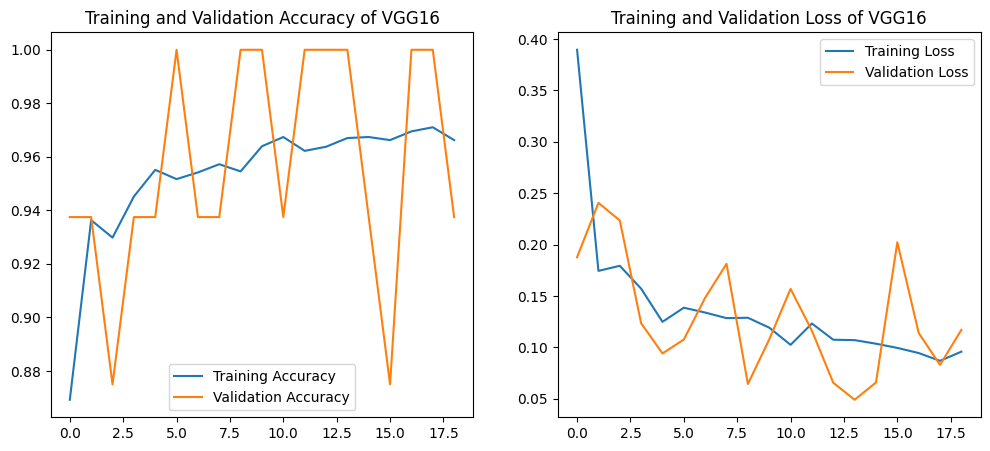

In [ ]:
# Evaluate VGG16 model

test_loss, test_acc = VGGmodel.evaluate(test_gen_rgb)
print(f"Test Accuracy of VGG16: {test_acc*100:.2f}%")

train_loss, train_acc = VGGmodel.evaluate(train_gen_rgb)
print(f"Train Accuracy of VGG16: {train_acc*100:.2f}%")

# Plot the training history for accuracy and loss
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(VGGhistory1.history['accuracy'], label='Training Accuracy')
plt.plot(VGGhistory1.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy of VGG16')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(VGGhistory1.history['loss'], label='Training Loss')
plt.plot(VGGhistory1.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss of VGG16')
plt.legend()
plt.show()

In [ ]:
# Evaluate / Predict on test data
test_loss, test_acc = VGGmodel.evaluate(test_gen_rgb)
print(f"Test Accuracy: {test_acc*100:.2f}%")

y_predV = VGGmodel.predict(test_gen_rgb, steps=len(test_gen_rgb))
y_predV = np.round(y_predV).astype(int)
y_trueV = test_gen_rgb.classes
y_trueV = y_trueV[:len(y_predV)]

20/20 [==============================] - 10s 507ms/step - loss: 0.3193 - accuracy: 0.9119
Test Accuracy: 91.19%
20/20 [==============================] - 7s 330ms/step


In [ ]:
# Classification Report
print(confusion_matrix(test_gen_rgb.classes, y_predV > 0.5))
pd.DataFrame(classification_report(test_gen_rgb.classes, y_predV > 0.5, output_dict=True))

[[187  47]
 [  8 382]]


,0,1,accuracy,macro avg,weighted avg
precision,0.958974,0.890443,0.911859,0.924709,0.916142
recall,0.799145,0.979487,0.911859,0.889316,0.911859
f1-score,0.871795,0.932845,0.911859,0.902320,0.909951
support,234.000000,390.000000,0.911859,624.000000,624.000000


In [ ]:
# ROC AUC
roc_auc = roc_auc_score(y_trueV, y_predV)
print(f"ROC AUC: {roc_auc:.2f}")

ROC AUC: 0.89


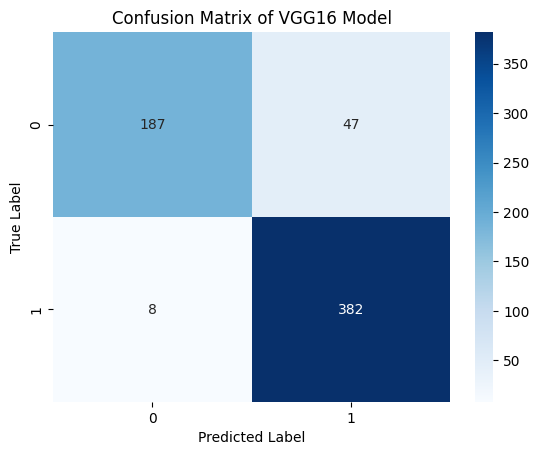

In [ ]:
# Plot confusion matrix heat map
cm = confusion_matrix(y_trueV, y_predV)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix of VGG16 Model')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [ ]:
tf.keras.backend.clear_session()

# Training & Evaluation: VGG16 Model - 2

In [ ]:
# Training the VGG model - 2
VGGhistory2 = VGGmodel.fit(
    train_gen_rgb,
    validation_data=val_gen_rgb,
    epochs=20,
    class_weight = class_weights,
    callbacks = [early_stopper,  learning_rate, model_checkpoint]
)

Epoch 1/20
163/163 [==============================] - ETA: 0s - loss: 0.3250 - accuracy: 0.8886

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


163/163 [==============================] - 1343s 8s/step - loss: 0.3250 - accuracy: 0.8886 - val_loss: 0.2432 - val_accuracy: 0.8750 - lr: 0.0010
Epoch 2/20
163/163 [==============================] - 151s 928ms/step - loss: 0.1642 - accuracy: 0.9358 - val_loss: 0.2214 - val_accuracy: 0.9375 - lr: 0.0010
Epoch 3/20
163/163 [==============================] - 150s 919ms/step - loss: 0.1552 - accuracy: 0.9440 - val_loss: 0.1964 - val_accuracy: 0.8750 - lr: 0.0010
Epoch 4/20
163/163 [==============================] - 144s 880ms/step - loss: 0.1337 - accuracy: 0.9498 - val_loss: 0.1336 - val_accuracy: 0.9375 - lr: 0.0010
Epoch 5/20
163/163 [==============================] - 151s 928ms/step - loss: 0.1302 - accuracy: 0.9500 - val_loss: 0.1201 - val_accuracy: 0.9375 - lr: 0.0010
Epoch 6/20
163/163 [==============================] - 150s 919ms/step - loss: 0.1193 - accuracy: 0.9572 - val_loss: 0.1505 - val_accuracy: 0.9375 - lr: 0.0010
Epoch 7/20
163/163 [==============================] - 151s 

In [ ]:
# Check if early stopping was triggered
if early_stopper.stopped_epoch > 0:
    print(f"Training was stopped early at epoch: {early_stopper.stopped_epoch + 1}")
else:
    print("Training completed without early stopping.")

Training completed without early stopping.


20/20 [==============================] - 187s 10s/step - loss: 0.3488 - accuracy: 0.9167
Test Accuracy of VGG16: 91.67%
163/163 [==============================] - 152s 930ms/step - loss: 0.0494 - accuracy: 0.9812
Train Accuracy of VGG16: 98.12%


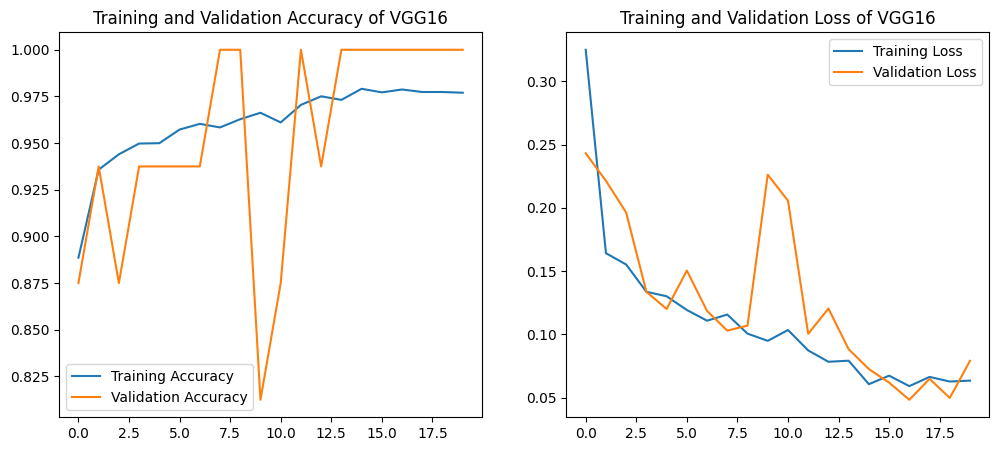

In [ ]:
# Evaluate VGG16 model
test_loss, test_acc = VGGmodel.evaluate(test_gen_rgb)
print(f"Test Accuracy of VGG16: {test_acc*100:.2f}%")

train_loss, train_acc = VGGmodel.evaluate(train_gen_rgb)
print(f"Train Accuracy of VGG16: {train_acc*100:.2f}%")

# Plot the training history for accuracy and loss
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(VGGhistory2.history['accuracy'], label='Training Accuracy')
plt.plot(VGGhistory2.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy of VGG16')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(VGGhistory2.history['loss'], label='Training Loss')
plt.plot(VGGhistory2.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss of VGG16')
plt.legend()
plt.show()

In [ ]:
# Evaluate / Predict on test data
test_loss, test_acc = VGGmodel.evaluate(test_gen_rgb)
print(f"Test Accuracy: {test_acc*100:.2f}%")

y_predV = VGGmodel.predict(test_gen_rgb, steps=len(test_gen_rgb))
y_predV = np.round(y_predV).astype(int)
y_trueV = test_gen_rgb.classes
y_trueV = y_trueV[:len(y_predV)]

20/20 [==============================] - 10s 451ms/step - loss: 0.3488 - accuracy: 0.9167
Test Accuracy: 91.67%
20/20 [==============================] - 9s 395ms/step


In [ ]:
# Classification Report
print(confusion_matrix(test_gen_rgb.classes, y_predV > 0.5))
pd.DataFrame(classification_report(test_gen_rgb.classes, y_predV > 0.5, output_dict=True))

[[187  47]
 [  5 385]]


,0,1,accuracy,macro avg,weighted avg
precision,0.973958,0.891204,0.916667,0.932581,0.922237
recall,0.799145,0.987179,0.916667,0.893162,0.916667
f1-score,0.877934,0.936740,0.916667,0.907337,0.914688
support,234.000000,390.000000,0.916667,624.000000,624.000000


In [ ]:
# ROC AUC
roc_auc = roc_auc_score(y_trueV, y_predV)
print(f"ROC AUC: {roc_auc:.2f}")

ROC AUC: 0.89


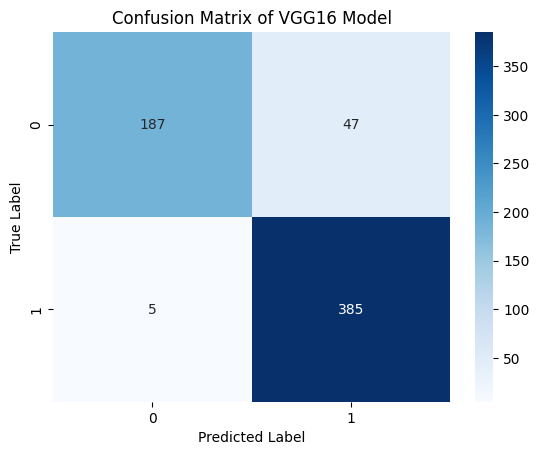

In [ ]:
# Plot confusion matrix heat map
cm = confusion_matrix(y_trueV, y_predV)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix of VGG16 Model')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [ ]:
tf.keras.backend.clear_session()